# Mobile DAU KPI — cumulative "cake" decomposition (August 2026 cycle)

**Standalone diagnostic.** Reads the cycle's canonical mobile build and its adjustment specs and
produces one chart: the published mobile DAU KPI line broken into the three things that actually
build it, as **cumulative** layers.

| layer | what it is | who produced it |
|---|---|---|
| 1. **Organic** | organic mobile DAU — measured before the seam, forecast by mozaic after it | the model |
| 2. **+ Paid marketing** | measured paid before the seam, marketing's paid *level* after it | measurement + marketing's model |
| 3. **+ Headwinds & tailwinds** | `h` (Win10, −27,162 mobile) + `t` (discretionary, **+299,000**) | judgement |

Layer 3 **is** the published KPI line. Layer 2 is the forecast parquet's own total. So the gap
between lines 2 and 3 is exactly the display-layer adjustment, and the gap between 1 and 2 is paid.

## Why the layers are drawn this way

- **`t` gets its own band, never folded into organic.** It is a discretionary overlay, ~47%
  evidence-backed, and its final +23,000 was sized to land published mobile within 1,000 DAU of
  July's delivered figure. Putting it inside a band labelled "forecast by mozaic" would hide exactly
  what keeping `t` separate from `h` was meant to expose.
- **Organic is derived as `model total − paid`, not modelled separately.** The bands therefore sum
  to the published headline by construction, and the notebook asserts that.
- **Before the seam every layer is actuals.** `h` and `t` are zero there, so lines 2 and 3 coincide.

Chart: `plots/mobile_kpi_cake.png`. Numbers here are the same ones in
`csv/august_dec15_summary.csv`; see `_index.md` for the attribution ledger.


In [1]:
# [setup]
# Standalone: this notebook does not import anything from the canonical review notebook.
import json
import os
import subprocess
import sys
from pathlib import Path

# Anchor execution at the git root so the relative paths below work regardless of where this
# notebook is launched from (jupyter and nbconvert both default cwd to the notebook's directory).
os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True, check=True).stdout.strip())

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

sys.path.insert(0, "src")

from mozaic_daily.adjustments import load_forecast, render_adjustment  # noqa: E402
from mozaic_daily.organic import (  # noqa: E402
    build_share_lookup,
    load_organic_spec,
    load_split_frame,
    marketing_paid_level,
    split_training_to_organic,
)
from mozaic_daily.seam_ma import display_ma  # noqa: E402

CYCLE_DIR = Path("data-official/2026-08")
MOBILE_FORECAST_PATH = (
    CYCLE_DIR
    / "mobile_cpr0725_2026-08-02"
    / "cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1"
    / "mozaic_daily_forecast.2026-08-02.gm-D.adj-p.parquet"
)
ORGANIC_SPEC_DIR = CYCLE_DIR / "organic"
ADJUSTMENTS_DIR = CYCLE_DIR / "adjustments"
PLOTS_DIR = CYCLE_DIR / "plots"
PLOT_PATH = PLOTS_DIR / "mobile_kpi_cake.png"

SEAM = pd.Timestamp("2026-08-02")          # actuals -> forecast boundary
FORECAST_END = pd.Timestamp("2027-12-31")  # marketing level is built out to the model horizon
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# Pinned so a silent rebuild cannot change the chart without failing here first.
EXPECTED_PUBLISHED_DEC15 = 17_924_562

# --- DRAFT watermark: OFF, but wired ------------------------------------------------------------
# Mobile was signed off 2026-08-03, so the watermark is suppressed. It is expected to be REAPPLIED,
# so the helper and its call site are deliberately left in place -- flip this one flag to bring it
# back. Kept deliberately identical to the canonical notebook's [helpers] version so the two mobile
# chart sets can never disagree about whether they are watermarked.
SHOW_DRAFT_WATERMARK = False


def add_draft_watermark(ax, text="DRAFT"):
    """Stamp a large diagonal DRAFT watermark across an axes, unless suppressed.

    No-ops when SHOW_DRAFT_WATERMARK is False. Turning it off does NOT retire the caveat: 1.67% of
    published mobile Dec-15 is the discretionary `t` overlay, and its last +23,000 was sized to land
    the total within 1,000 DAU of July's figure.
    """
    if not SHOW_DRAFT_WATERMARK:
        return
    ax.text(0.5, 0.5, text, transform=ax.transAxes, fontsize=120, color="#c0392b",
            alpha=0.13, ha="center", va="center", rotation=28, zorder=100,
            fontweight="bold", clip_on=True)

print(f"mobile build : {MOBILE_FORECAST_PATH.name}")
print(f"seam         : {SEAM.date()}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


mobile build : mozaic_daily_forecast.2026-08-02.gm-D.adj-p.parquet
seam         : 2026-08-02


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [load-total]
# The published mobile KPI is the world ALL MOBILE row. Loading through load_forecast (not bare
# read_parquet) enforces the artifact contract and pins that `p` really is applied.
mobile_df, mobile_meta = load_forecast(MOBILE_FORECAST_PATH, require_state=["p"])

world = mobile_df[
    (mobile_df["country"] == "ALL")
    & (mobile_df["segment"] == "{}")
    & (mobile_df["data_source"] == "glean_mobile")
    & (mobile_df["app_name"] == "ALL MOBILE")
].copy()
world["target_date"] = pd.to_datetime(world["target_date"])
world = world.sort_values("target_date").reset_index(drop=True)

# Model total, 28d MA, with the variance-matched seam transition the published curves use.
model_total_ma = display_ma(world["target_date"], world["dau"], SEAM)

print(f"config : cpr={mobile_meta['model_config']['prophet_changepoint_range']}, "
      f"cps={mobile_meta['model_config']['prophet_changepoint_prior_scale']}, "
      f"regime={mobile_meta['model_config']['seasonality_regime']}")
print(f"rows   : {len(world):,}  ({world['target_date'].min().date()} .. "
      f"{world['target_date'].max().date()})")


config : cpr=0.725, cps=0.035, regime=auto
rows   : 2,557  (2020-12-31 .. 2027-12-31)


In [3]:
# [paid-series]
# Paid is TWO different things either side of the seam, and that is deliberate:
#   before  -> our MEASURED paid, from the client-level growth-source split (so training rows stay
#              byte-identical to raw actuals)
#   after   -> MARKETING's paid LEVEL (their lift curve + the anchor), held flat past its end
# The step between them at the seam is the honest size of the disagreement between our measurement
# and marketing's model. It is reported, never smoothed.
organic_spec = load_organic_spec(ORGANIC_SPEC_DIR / "organic.json")
split_frame = load_split_frame(organic_spec, ORGANIC_SPEC_DIR)

# The raw BQ pull is model-config independent; the build dir symlinks the cycle's single copy.
raw_mobile = pd.read_parquet(
    MOBILE_FORECAST_PATH.parent / "mozaic_parts.raw.glean.mobile.DAU.parquet"
).assign(x=lambda frame: pd.to_datetime(frame["x"]))

excluded = organic_spec["scope"]["exclude_countries"]
share_lookup = build_share_lookup(
    split_frame,
    share_column=organic_spec["share_column"],
    training_dates=pd.DatetimeIndex(sorted(raw_mobile["x"].unique())),
    countries=sorted(set(raw_mobile["country"].unique()) - set(excluded)),
)
_, measured_paid = split_training_to_organic(
    raw_mobile, share_lookup=share_lookup, exclude_countries=excluded
)
marketing_paid = marketing_paid_level(
    organic_spec, ORGANIC_SPEC_DIR, forecast_start=SEAM, forecast_end=FORECAST_END
)

paid_daily = pd.concat([
    measured_paid.groupby(level="submission_date").sum(),
    marketing_paid[marketing_paid.index >= SEAM],
]).sort_index()
paid_ma = paid_daily.rolling(28).mean()

seam_step = marketing_paid.loc[SEAM] - measured_paid.groupby(level="submission_date").sum().iloc[-1]
print(f"paid at Dec-15 (28d MA) : {paid_ma.loc[MEASUREMENT_DATE]:>12,.0f}")
print(f"paid seam step (daily)  : {seam_step:>+12,.0f}  "
      f"(measurement -> marketing's model; reported, not smoothed)")


paid at Dec-15 (28d MA) :    1,554,879
paid seam step (daily)  :       +1,903  (measurement -> marketing's model; reported, not smoothed)


In [4]:
# [decompose]
# The three CUMULATIVE layers. Each one is the previous plus one contribution, so the top line is
# the published KPI and the vertical gaps are the contributions themselves.
net_adjustment = render_adjustment(json.load(open(ADJUSTMENTS_DIR / "headwind.json")), model_total_ma.index)
tailwind = render_adjustment(json.load(open(ADJUSTMENTS_DIR / "tailwind.json")), model_total_ma.index)
adjustment_mobile = net_adjustment["mobile"] + tailwind["mobile"]
# History is actuals and must never be moved: the ramps apply only from the seam forward.
adjustment_mobile[model_total_ma.index < SEAM] = 0.0

paid_aligned = paid_ma.reindex(model_total_ma.index)

layer_organic = model_total_ma - paid_aligned          # 1: organic only
layer_with_paid = model_total_ma                       # 2: + paid marketing
layer_published = model_total_ma + adjustment_mobile   # 3: + headwinds & tailwinds  == published KPI

cake = pd.DataFrame({
    "organic": layer_organic,
    "organic_plus_paid": layer_with_paid,
    "published": layer_published,
}).loc[DISPLAY_START:DISPLAY_END].dropna()

# --- Assertions, not eyeballs ---------------------------------------------------------------
published_dec15 = cake.loc[MEASUREMENT_DATE, "published"]
assert abs(published_dec15 - EXPECTED_PUBLISHED_DEC15) < 1, (
    f"published Dec-15 is {published_dec15:,.0f} but this notebook is pinned to "
    f"{EXPECTED_PUBLISHED_DEC15:,}. Either the build changed or a spec moved -- do not trust the "
    f"chart until this is resolved."
)
# The bands must reconstruct the headline exactly, or the chart is lying about what composes it.
reconstruction = (
    cake["organic"]
    + (cake["organic_plus_paid"] - cake["organic"])
    + (cake["published"] - cake["organic_plus_paid"])
)
assert (reconstruction - cake["published"]).abs().max() < 1e-6, "bands do not sum to the published line"
# Before the seam there is no adjustment, so layers 2 and 3 must coincide.
pre_seam = cake.loc[cake.index < SEAM]
assert (pre_seam["published"] - pre_seam["organic_plus_paid"]).abs().max() < 1e-6, (
    "layers 2 and 3 diverge before the seam -- an adjustment is leaking into history"
)

print(f"{'date':12}{'organic':>14}{'+ paid':>14}{'+ h & t':>14}{'paid':>12}{'h+t':>11}")
for date in ("2026-01-01", "2026-07-27", str(SEAM.date()), "2026-08-24", "2026-12-15"):
    row = cake.loc[date]
    print(f"{date:12}{row['organic']:>14,.0f}{row['organic_plus_paid']:>14,.0f}"
          f"{row['published']:>14,.0f}{row['organic_plus_paid']-row['organic']:>12,.0f}"
          f"{row['published']-row['organic_plus_paid']:>11,.0f}")


date               organic        + paid       + h & t        paid        h+t
2026-01-01      14,726,204    15,465,127    15,465,127     738,922          0
2026-07-27      15,605,584    17,082,290    17,082,290   1,476,706          0
2026-08-02      15,578,640    17,079,289    17,079,289   1,500,648          0
2026-08-24      15,545,318    17,066,841    17,111,141   1,521,524     44,300
2026-12-15      16,097,845    17,652,724    17,924,562   1,554,879    271,838


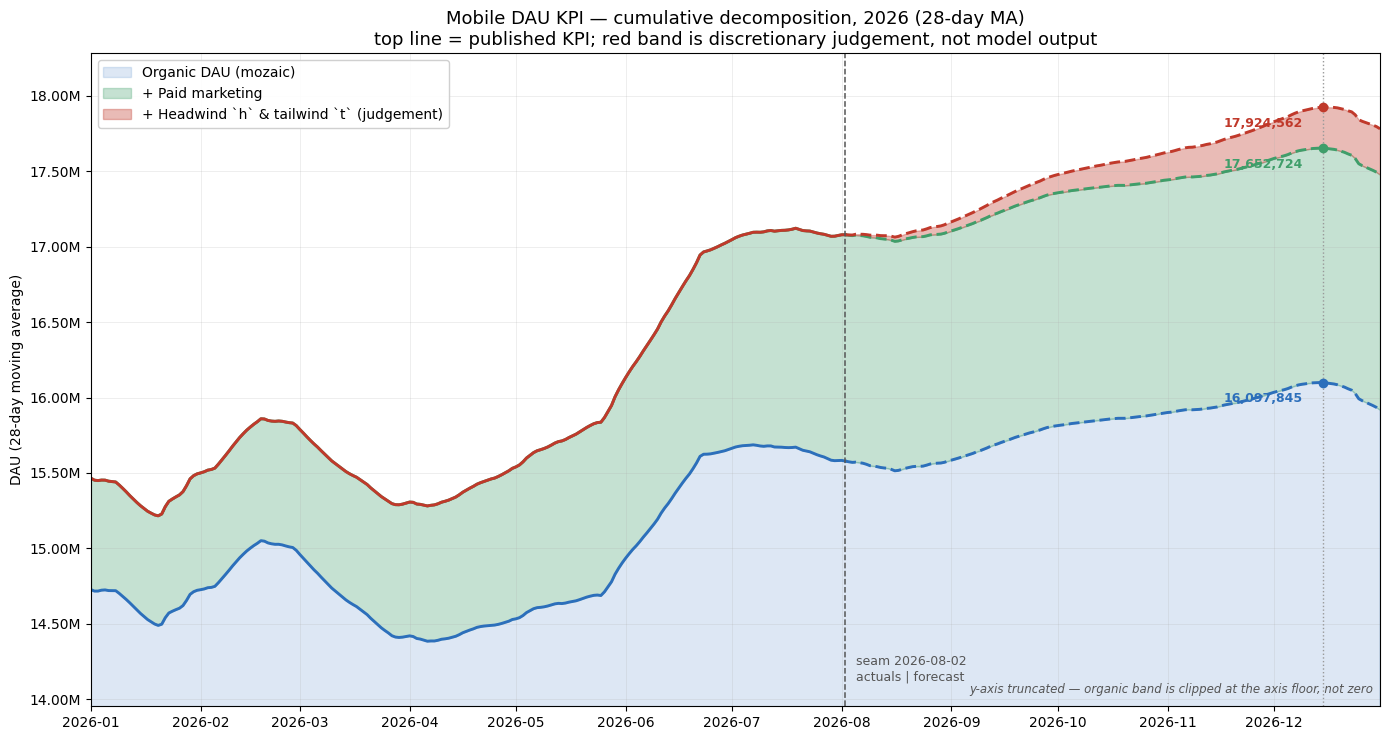

saved data-official/2026-08/plots/mobile_kpi_cake.png


In [5]:
# [plot-cake]
# Cumulative bands. Solid to the seam (actuals), dashed after it (forecast), so the reader can see
# at a glance which part of every layer is measured.
millions = FuncFormatter(lambda value, _: f"{value / 1e6:.2f}M")

BAND_COLOURS = {
    "organic": "#2c6fbb",    # the model's own output
    "paid": "#3f9e6a",       # measured / marketing's model
    "adjustment": "#c0392b", # judgement
}

fig, ax = plt.subplots(figsize=(14, 7.5))

# Bands, bottom to top. Drawn first so the lines sit on top of them.
ax.fill_between(cake.index, 0, cake["organic"],
                color=BAND_COLOURS["organic"], alpha=0.16, label="Organic DAU (mozaic)")
ax.fill_between(cake.index, cake["organic"], cake["organic_plus_paid"],
                color=BAND_COLOURS["paid"], alpha=0.30, label="+ Paid marketing")
ax.fill_between(cake.index, cake["organic_plus_paid"], cake["published"],
                color=BAND_COLOURS["adjustment"], alpha=0.34,
                label="+ Headwind `h` & tailwind `t` (judgement)")

for column, colour in (("organic", BAND_COLOURS["organic"]),
                       ("organic_plus_paid", BAND_COLOURS["paid"]),
                       ("published", BAND_COLOURS["adjustment"])):
    series = cake[column]
    ax.plot(series.loc[:SEAM].index, series.loc[:SEAM], color=colour, lw=2.1)
    ax.plot(series.loc[SEAM:].index, series.loc[SEAM:], color=colour, lw=2.1, ls="--")

ax.axvline(SEAM, color="#555", ls="--", lw=1.1)
# Anchor in (data, axes-fraction) so the label survives the set_ylim below -- anchoring to
# get_ylim() before the limits are set pushes it off-canvas.
ax.annotate(f"seam {SEAM.date()}\nactuals | forecast", xy=(SEAM, 0.035),
            xycoords=("data", "axes fraction"), xytext=(8, 0),
            textcoords="offset points", fontsize=9, color="#555", va="bottom")

# Dec-15 callouts -- the KPI date, and the only place the three layers are quoted.
for column, colour in (("organic", BAND_COLOURS["organic"]),
                       ("organic_plus_paid", BAND_COLOURS["paid"]),
                       ("published", BAND_COLOURS["adjustment"])):
    value = cake.loc[MEASUREMENT_DATE, column]
    ax.plot([MEASUREMENT_DATE], [value], "o", color=colour, ms=6, zorder=6)
    ax.annotate(f"{value:,.0f}", xy=(MEASUREMENT_DATE, value), xytext=(-72, -14),
                textcoords="offset points", fontsize=9, color=colour, fontweight="bold")
ax.axvline(MEASUREMENT_DATE, color="#999", ls=":", lw=1)

# Currently a no-op -- mobile is signed off. Left in place so the watermark can be reapplied by
# flipping SHOW_DRAFT_WATERMARK in [setup]. See that flag's comment.
add_draft_watermark(ax)

ax.set_title("Mobile DAU KPI — cumulative decomposition, 2026 (28-day MA)\n"
             "top line = published KPI; red band is discretionary judgement, not model output",
             fontsize=13)
ax.set_ylabel("DAU (28-day moving average)")
ax.set_xlim(DISPLAY_START, DISPLAY_END)
# Start the axis below the organic band rather than at zero: the bands are a few percent of the
# total, and a zero-based axis would compress all three into one indistinguishable stripe.
ax.set_ylim(cake["organic"].min() * 0.97, cake["published"].max() * 1.02)
ax.yaxis.set_major_formatter(millions)
ax.grid(alpha=0.25, lw=0.6)
ax.legend(loc="upper left", framealpha=0.92, fontsize=10)
# The axis is truncated (see set_ylim above), so the organic band is clipped at the axis floor
# rather than running to zero. Say so on the chart -- a clipped band reads as a thin band.
ax.text(0.995, 0.015, "y-axis truncated — organic band is clipped at the axis floor, not zero",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color="#555",
        style="italic")
fig.tight_layout()

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_PATH, dpi=140)
plt.show()
print(f"saved {PLOT_PATH}")


In [6]:
# [monthly-contributions]
# Month-end snapshot of each contribution, as a level and as a share of the published total.
month_ends = cake.resample("ME").last()
month_ends["paid"] = month_ends["organic_plus_paid"] - month_ends["organic"]
month_ends["adjustment"] = month_ends["published"] - month_ends["organic_plus_paid"]

print(f"{'month':9}{'published':>14}{'organic':>14}{'paid':>12}{'paid %':>9}"
      f"{'h+t':>11}{'h+t %':>8}")
for date, row in month_ends.iterrows():
    print(f"{date.strftime('%Y-%m'):9}{row['published']:>14,.0f}{row['organic']:>14,.0f}"
          f"{row['paid']:>12,.0f}{row['paid'] / row['published'] * 100:>8.1f}%"
          f"{row['adjustment']:>11,.0f}{row['adjustment'] / row['published'] * 100:>7.2f}%")

print("\nAt the Dec-15 KPI date:")
row = cake.loc[MEASUREMENT_DATE]
paid = row["organic_plus_paid"] - row["organic"]
adjustment = row["published"] - row["organic_plus_paid"]
print(f"  organic                {row['organic']:>14,.0f}  {row['organic']/row['published']*100:>6.2f}%")
print(f"  paid marketing         {paid:>14,.0f}  {paid/row['published']*100:>6.2f}%")
print(f"  headwind + tailwind    {adjustment:>14,.0f}  {adjustment/row['published']*100:>6.2f}%")
print(f"  = PUBLISHED            {row['published']:>14,.0f}")
print("\nThe h+t band nets a POSITIVE +271,838 at Dec-15 (`t` +299,000 minus `h` -27,162).")
print("Of that, +23,000 exists only to land the published total within 1,000 DAU of July's")
print("delivered 17,923,869 -- calibration to a prior published number, not a measurement.")


month         published       organic        paid   paid %        h+t   h+t %
2026-01      15,493,941    14,721,761     772,179     5.0%          0   0.00%
2026-02      15,813,538    14,986,338     827,200     5.2%          0   0.00%
2026-03      15,299,663    14,415,192     884,471     5.8%          0   0.00%
2026-04      15,530,409    14,528,041   1,002,369     6.5%          0   0.00%
2026-05      16,093,196    14,902,945   1,190,250     7.4%          0   0.00%
2026-06      17,034,645    15,655,155   1,379,490     8.1%          0   0.00%
2026-07      17,074,482    15,581,825   1,492,657     8.7%          0   0.00%
2026-08      17,155,752    15,578,128   1,519,229     8.9%     58,395   0.34%
2026-09      17,472,000    15,810,383   1,542,813     8.8%    118,803   0.68%
2026-10      17,621,872    15,898,058   1,542,589     8.8%    181,225   1.03%
2026-11      17,819,014    16,027,415   1,549,965     8.7%    241,634   1.36%
2026-12      17,781,956    15,917,634   1,560,265     8.8%    30